# IPL Analytics & Match Outcome Prediction Platform

## End-to-End Data Analytics and Machine Learning Project

### Developed By

**Shibang Maity**

---

## Technologies Used

* Python
* SQL (SQLite)
* Pandas
* NumPy
* Matplotlib
* Plotly *(will be added later)*
* Scikit-learn
* XGBoost
* SHAP
* Streamlit

---

# Project Objective

The objective of this project is to analyze historical IPL data using SQL and Python, generate meaningful business insights through exploratory data analysis, and build a machine learning model capable of predicting IPL match outcomes.

---
# Table of Contents

1. Dataset Description
2. Import Libraries
3. Data Loading
4. Data Understanding
5. Data Cleaning
6. Exploratory Data Analysis (EDA)
7. SQL Analytics
   - Team Analytics
   - Venue Analytics
   - Player Analytics
   - Head-to-Head Analytics
8. Feature Engineering
9. Machine Learning
10. Model Evaluation
11. Explainable AI (SHAP)
12. Match Prediction
13. Conclusion
14. Future Scope


# Dataset Description

This project uses two IPL datasets.

### 1. matches.csv

Contains match-level information including:

* Match ID
* Season
* Teams
* Venue
* Toss Winner
* Toss Decision
* Match Winner
* Target Runs
* Target Overs
* Match Result

### 2. deliveries.csv

Contains ball-by-ball information including:

* Match ID
* Innings
* Over
* Batter
* Bowler
* Runs Scored
* Extras
* Wickets
* Dismissal Type

These datasets are used for SQL analytics, exploratory data analysis, feature engineering, and machine learning.

---


# Dataset Source

The datasets used in this project were obtained from the Kaggle IPL historical dataset. The data contains both match-level and ball-by-ball information across multiple IPL seasons and is widely used for sports analytics and machine learning projects.

---

# Import Libraries

The following libraries are imported for data manipulation, data visualization, machine learning, explainable AI, and database operations.

---

# Data Loading

The IPL datasets (`matches.csv` and `deliveries.csv`) are loaded into Pandas DataFrames for preprocessing, exploratory data analysis, SQL analytics, and machine learning.

---

# Data Understanding

* Dataset Shape
* Dataset Information
* Data Types
* Missing Values
* Unique Teams
* Seasons
* Venues

---

# Data Cleaning

* Standardize Team Names
* Remove Duplicate Records
* Handle Missing Values
* Correct Team Name Changes

---

# Exploratory Data Analysis (EDA)

Examples:

* Season-wise Matches
* Toss Decision Analysis
* Toss Winner Analysis
* Match Result Analysis
* Team Performance
* Top Run Scorers
* Top Wicket Takers

---

# SQL Analytics

## Team Analytics

* Top Teams by Wins
* Win Percentage
* Team Performance

## Venue Analytics

* Top Venues by Matches Hosted
* Highest Scoring Venues
* Venue Statistics

## Player Analytics

* Top Run Scorers
* Top Wicket Takers
* Most Sixes
* Most Fours

## Head-to-Head Analytics

* Team vs Team Performance

---

# Feature Engineering

Examples:

* Head-to-Head Win Rate
* Team Form
* Venue Encoding
* Toss Winner Encoding
* Rolling Win Percentage

---

# Machine Learning

Models Used:

* Logistic Regression
* Random Forest
* XGBoost

---

# Model Evaluation

Evaluation Metrics:

* Accuracy
* Precision
* Recall
* F1-Score
* Confusion Matrix

---

# Explainable AI (SHAP)

* Feature Importance
* SHAP Summary Plot
* Model Interpretation

---

# Match Prediction

Predict the winning team based on:

* Team 1
* Team 2
* Venue
* Toss Winner
* Toss Decision

---

# Conclusion

Summarize the major insights obtained from SQL analytics, exploratory data analysis, and machine learning.

---

# Future Scope

Possible future improvements:

* Live IPL API integration
* Player performance forecasting
* Real-time dashboard updates
* Advanced ensemble models
* Cloud deployment


In [64]:
!pip install xgboost

In [65]:
!pip install shap

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("\nMatches columns:", matches.columns.tolist())
print("\nDeliveries columns:", deliveries.columns.tolist())

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [13]:
# Check date range and seasons
print("Seasons:", sorted(matches['season'].unique()))
print("Total matches:", len(matches))
print("Teams:", matches['team1'].unique())

# Check nulls
print("\nNull values in matches:")
print(matches.isnull().sum())

Seasons: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2021', '2022', '2023', '2024']
Total matches: 1090
Teams: ['Royal Challengers Bengaluru' 'Punjab Kings' 'Delhi Capitals'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Lucknow Super Giants' 'Gujarat Titans']

Null values in matches:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


In [14]:
# Fix season names to just year
season_map = {
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2021'
}
matches['season'] = matches['season'].replace(season_map)

# Fix team name inconsistencies
team_map = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_map)

deliveries['batting_team'] = deliveries['batting_team'].replace(team_map)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_map)

# Drop no-result matches (winner is null = abandoned/no result)
matches = matches.dropna(subset=['winner'])



In [16]:
print("Matches after cleaning:", len(matches))
print("Seasons:", sorted(matches['season'].unique()))
print("Unique teams:", sorted(matches['team1'].unique()))

Matches after cleaning: 1090
Seasons: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2021', '2022', '2023', '2024']
Unique teams: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


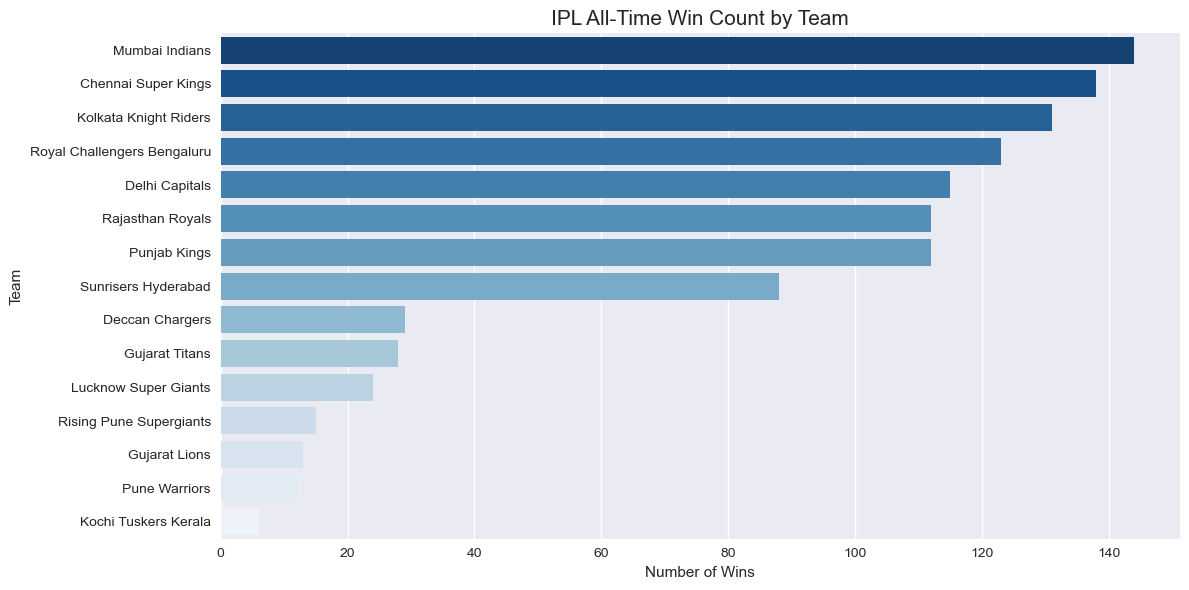

In [17]:
# 1. Most successful teams
win_counts = matches['winner'].value_counts().reset_index()
win_counts.columns = ['team', 'wins']

plt.figure(figsize=(12, 6))
sns.barplot(data=win_counts, x='wins', y='team', palette='Blues_r')
plt.title('IPL All-Time Win Count by Team', fontsize=15)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('team_wins.png', dpi=150)
plt.show()

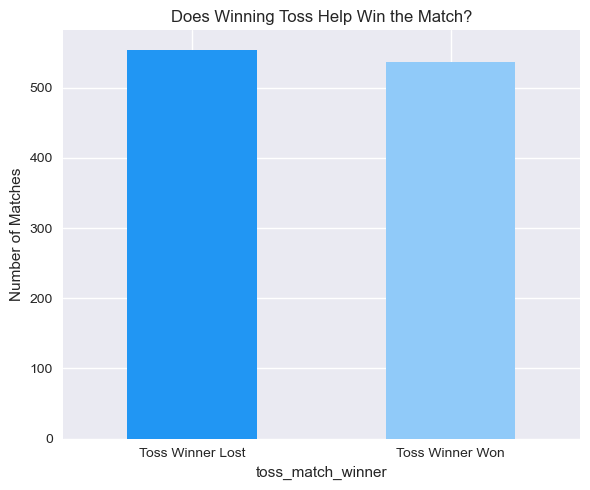

Toss winner also won match: 554 / 1090 = 50.8%


In [18]:
# 2. Toss impact — does winning toss help win match?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_match_winner'].value_counts()

plt.figure(figsize=(6, 5))
toss_impact.plot(kind='bar', color=['#2196F3', '#90CAF9'])
plt.xticks([0, 1], ['Toss Winner Lost', 'Toss Winner Won'], rotation=0)
plt.title('Does Winning Toss Help Win the Match?')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.savefig('toss_impact.png', dpi=150)
plt.show()

print(f"Toss winner also won match: {toss_impact[True]} / {len(matches)} = {toss_impact[True]/len(matches)*100:.1f}%")

<Figure size 1200x500 with 0 Axes>

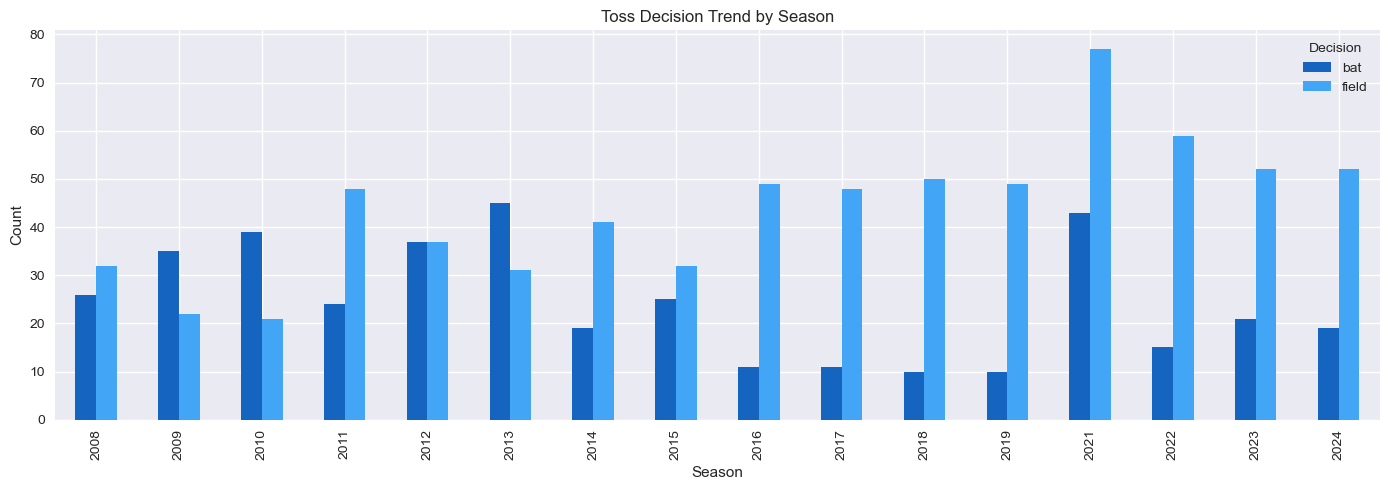

In [19]:
# 3. Toss decision preference over seasons
plt.figure(figsize=(12, 5))
toss_decision = matches.groupby(['season', 'toss_decision']).size().unstack()
toss_decision.plot(kind='bar', figsize=(14, 5), color=['#1565C0', '#42A5F5'])
plt.title('Toss Decision Trend by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Decision')
plt.tight_layout()
plt.savefig('toss_decision_trend.png', dpi=150)
plt.show()

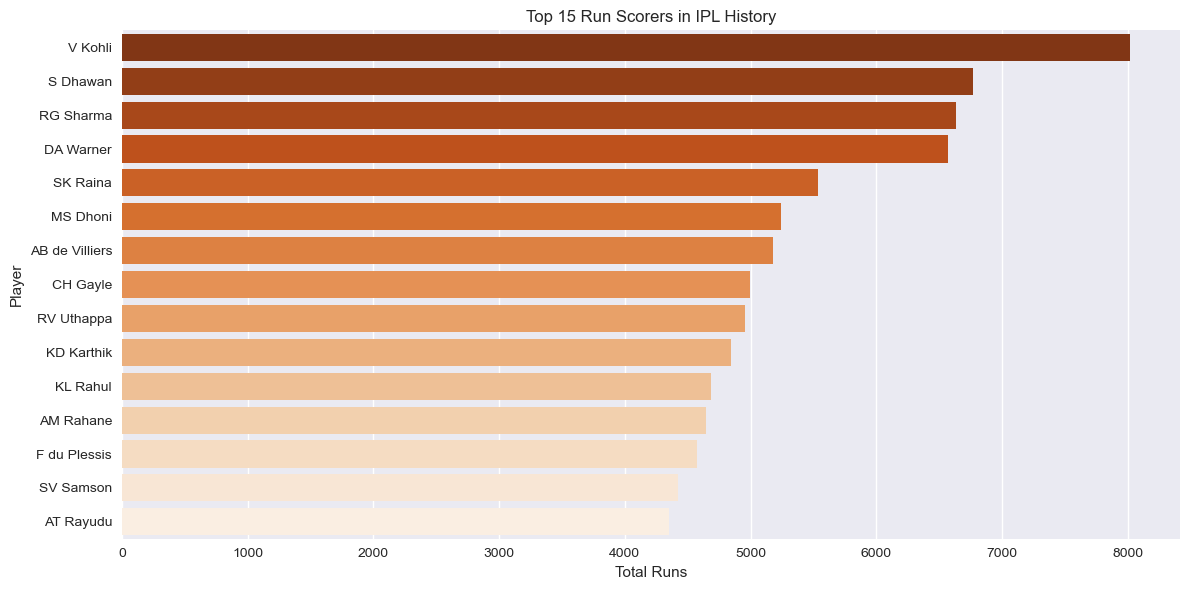

In [20]:
# 4. Top run scorers
runs = deliveries.groupby('batter')['batsman_runs'].sum().reset_index()
runs.columns = ['batter', 'total_runs']
runs = runs.sort_values('total_runs', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=runs, x='total_runs', y='batter', palette='Oranges_r')
plt.title('Top 15 Run Scorers in IPL History')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('top_batters.png', dpi=150)
plt.show()

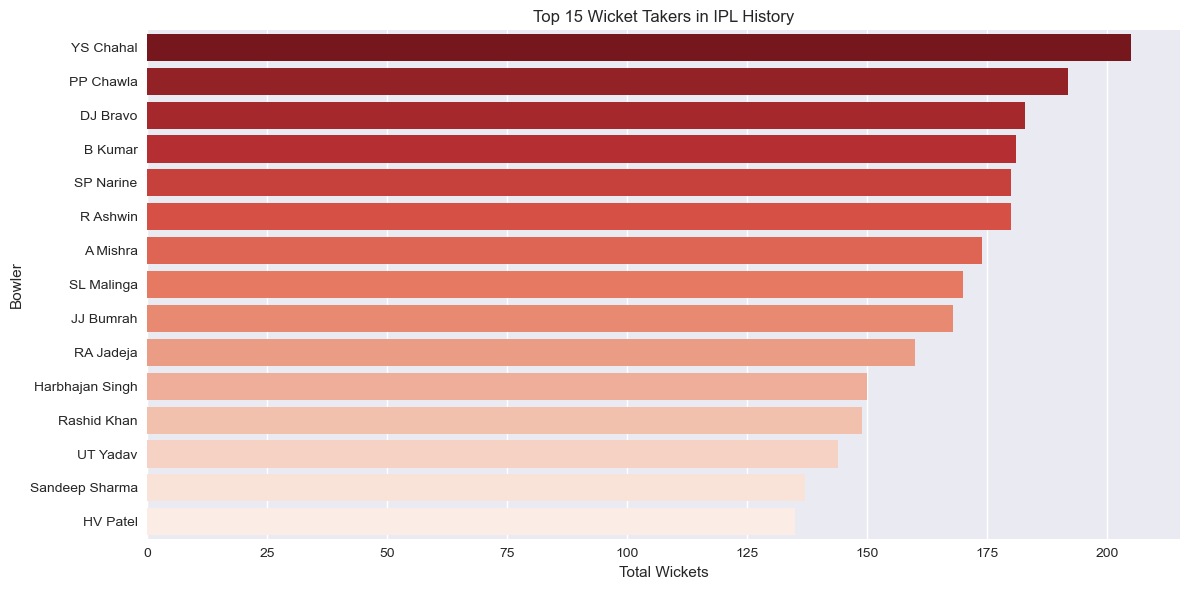

In [21]:
# 5. Top wicket takers
wickets = deliveries[deliveries['is_wicket'] == 1]
wickets = wickets[~wickets['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
wicket_counts = wickets.groupby('bowler')['is_wicket'].count().reset_index()
wicket_counts.columns = ['bowler', 'wickets']
wicket_counts = wicket_counts.sort_values('wickets', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=wicket_counts, x='wickets', y='bowler', palette='Reds_r')
plt.title('Top 15 Wicket Takers in IPL History')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('top_bowlers.png', dpi=150)
plt.show()

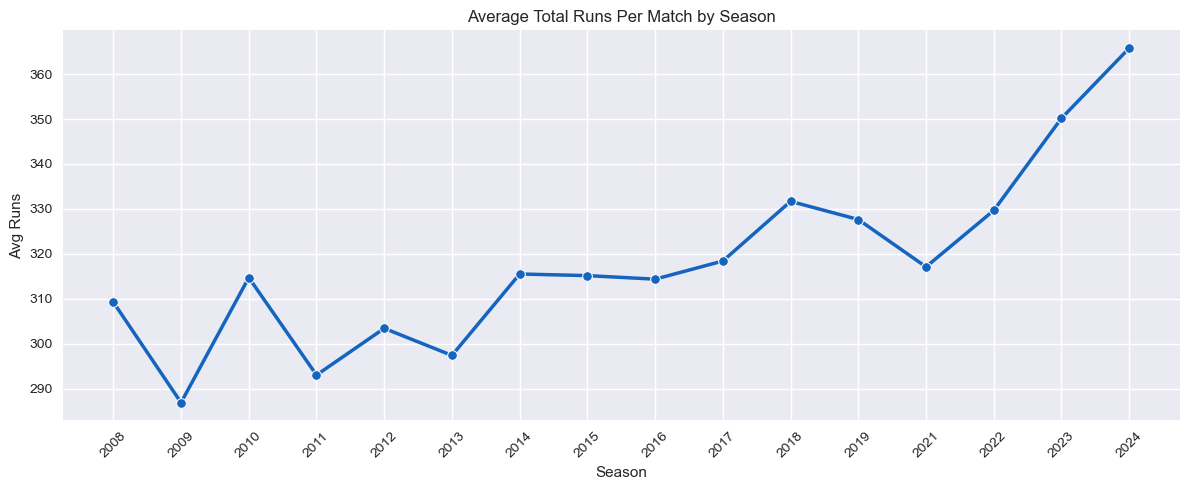

In [22]:
# 6. Season-wise avg match scores
season_scores = deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
avg_score = season_scores.groupby(['season', 'match_id'])['total_runs'].sum().reset_index()
avg_score = avg_score.groupby('season')['total_runs'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=avg_score, x='season', y='total_runs', marker='o', color='#1565C0', linewidth=2.5)
plt.title('Average Total Runs Per Match by Season')
plt.xlabel('Season')
plt.ylabel('Avg Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('season_scores.png', dpi=150)
plt.show()

In [23]:
# Feature Engineering for Match Outcome Prediction

# Toss feature — did toss winner choose to bat or field
matches['toss_win_bat'] = ((matches['toss_winner'] == matches['team1']) & 
                            (matches['toss_decision'] == 'bat') | 
                           (matches['toss_winner'] == matches['team2']) & 
                            (matches['toss_decision'] == 'bat')).astype(int)

# Did team1 win toss?
matches['team1_won_toss'] = (matches['toss_winner'] == matches['team1']).astype(int)

# Target — did team1 win?
matches['team1_won'] = (matches['winner'] == matches['team1']).astype(int)

# Head to head win rate (team1 vs team2 historically)
def h2h_winrate(df):
    h2h = {}
    rates = []
    for _, row in df.iterrows():
        key = tuple(sorted([row['team1'], row['team2']]))
        if key not in h2h:
            h2h[key] = {'team1_wins': 0, 'total': 0}
        total = h2h[key]['total']
        wins = h2h[key]['team1_wins']
        rates.append(wins / total if total > 0 else 0.5)
        h2h[key]['total'] += 1
        if row['winner'] == row['team1']:
            h2h[key]['team1_wins'] += 1
    return rates

matches = matches.sort_values('date').reset_index(drop=True)
matches['h2h_winrate'] = h2h_winrate(matches)

# Team overall win rate (rolling)
def rolling_winrate(df, team_col, result_col, window=10):
    rates = []
    team_history = {}
    for _, row in df.iterrows():
        team = row[team_col]
        if team not in team_history:
            team_history[team] = []
        history = team_history[team]
        if len(history) >= 3:
            rates.append(np.mean(history[-window:]))
        else:
            rates.append(0.5)
        team_history[team].append(1 if row[result_col] == team else 0)
    return rates

matches['team1_form'] = rolling_winrate(matches, 'team1', 'winner')
matches['team2_form'] = rolling_winrate(matches, 'team2', 'winner')

print("Features created successfully")
print(matches[['team1', 'team2', 'team1_won_toss', 'h2h_winrate', 'team1_form', 'team2_form', 'team1_won']].head(10))

Features created successfully
                         team1                        team2  team1_won_toss  \
0  Royal Challengers Bengaluru        Kolkata Knight Riders               1   
1                 Punjab Kings          Chennai Super Kings               0   
2               Delhi Capitals             Rajasthan Royals               0   
3               Mumbai Indians  Royal Challengers Bengaluru               1   
4        Kolkata Knight Riders              Deccan Chargers               0   
5             Rajasthan Royals                 Punjab Kings               0   
6              Deccan Chargers               Delhi Capitals               1   
7          Chennai Super Kings               Mumbai Indians               0   
8              Deccan Chargers             Rajasthan Royals               0   
9                 Punjab Kings               Mumbai Indians               0   

   h2h_winrate  team1_form  team2_form  team1_won  
0          0.5         0.5         0.5          

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# Encode team names
le = LabelEncoder()
all_teams = pd.concat([matches['team1'], matches['team2']]).unique()
le.fit(all_teams)

matches['team1_enc'] = le.transform(matches['team1'])
matches['team2_enc'] = le.transform(matches['team2'])

# Encode venue
venue_enc = LabelEncoder()
matches['venue_enc'] = venue_enc.fit_transform(matches['venue'])

# Final feature set
features = ['team1_enc', 'team2_enc', 'team1_won_toss', 'toss_win_bat',
            'h2h_winrate', 'team1_form', 'team2_form', 'venue_enc']

X = matches[features]
y = matches['team1_won']

# Train test split — use last 20% as test (time-based)
split = int(len(matches) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(classification_report(y_test, rf_preds))

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds)*100:.2f}%")
print(classification_report(y_test, xgb_preds))

=== Random Forest ===
Accuracy: 46.33%
              precision    recall  f1-score   support

           0       0.46      0.59      0.52       106
           1       0.47      0.34      0.39       112

    accuracy                           0.46       218
   macro avg       0.46      0.47      0.46       218
weighted avg       0.46      0.46      0.45       218

=== XGBoost ===
Accuracy: 45.41%
              precision    recall  f1-score   support

           0       0.45      0.51      0.48       106
           1       0.46      0.40      0.43       112

    accuracy                           0.45       218
   macro avg       0.46      0.46      0.45       218
weighted avg       0.46      0.45      0.45       218



In [27]:
# Better features — team overall win rate (all time, not rolling)
team_wins = matches['winner'].value_counts().to_dict()
total_matches = pd.concat([matches['team1'], matches['team2']]).value_counts().to_dict()

matches['team1_overall_wr'] = matches['team1'].map(
    lambda t: team_wins.get(t, 0) / total_matches.get(t, 1))
matches['team2_overall_wr'] = matches['team2'].map(
    lambda t: team_wins.get(t, 0) / total_matches.get(t, 1))

# Win rate difference
matches['wr_diff'] = matches['team1_overall_wr'] - matches['team2_overall_wr']
matches['form_diff'] = matches['team1_form'] - matches['team2_form']

# Season number (later seasons = different dynamics)
matches['season_num'] = matches['season'].astype(int)

# Updated feature set
features = ['team1_enc', 'team2_enc', 'team1_won_toss', 'toss_win_bat',
            'h2h_winrate', 'team1_form', 'team2_form', 'venue_enc',
            'team1_overall_wr', 'team2_overall_wr', 'wr_diff', 'form_diff', 'season_num']

X = matches[features]
y = matches['team1_won']

split = int(len(matches) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=10, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(classification_report(y_test, rf_preds))

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds)*100:.2f}%")
print(classification_report(y_test, xgb_preds))

=== Random Forest ===
Accuracy: 50.00%
              precision    recall  f1-score   support

           0       0.49      0.67      0.57       106
           1       0.52      0.34      0.41       112

    accuracy                           0.50       218
   macro avg       0.51      0.50      0.49       218
weighted avg       0.51      0.50      0.49       218

=== XGBoost ===
Accuracy: 44.95%
              precision    recall  f1-score   support

           0       0.45      0.63      0.53       106
           1       0.44      0.28      0.34       112

    accuracy                           0.45       218
   macro avg       0.45      0.45      0.43       218
weighted avg       0.45      0.45      0.43       218



=== Random Forest ===
Accuracy: 50.00%
              precision    recall  f1-score   support

           0       0.49      0.65      0.56       106
           1       0.52      0.36      0.42       112

    accuracy                           0.50       218
   macro avg       0.50      0.50      0.49       218
weighted avg       0.50      0.50      0.49       218



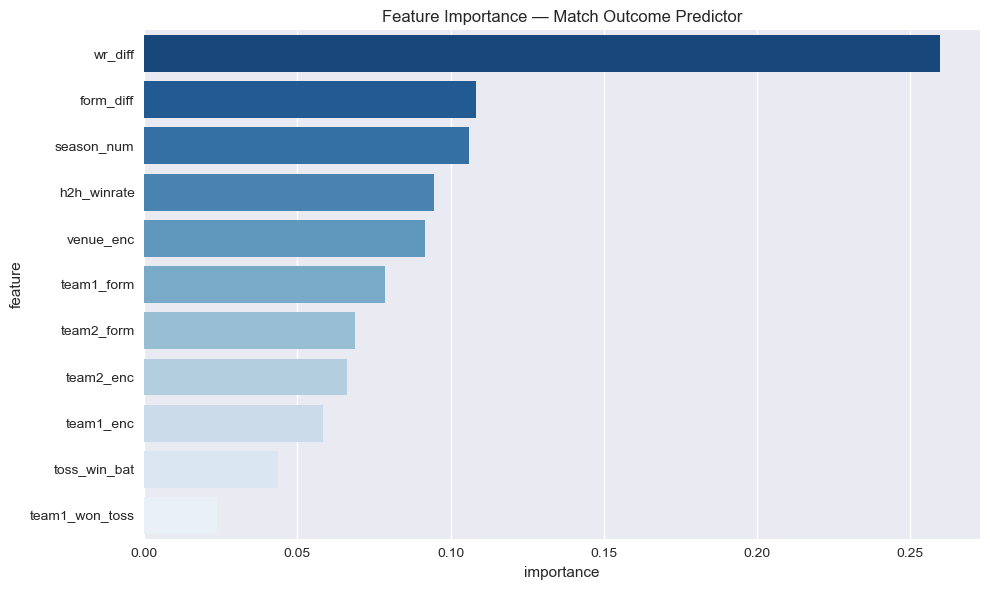

In [28]:
# Proper time-based rolling win rate (no leakage)
def proper_rolling_wr(df, team_col, window=15):
    rates = []
    team_history = {}
    for _, row in df.iterrows():
        team = row[team_col]
        if team not in team_history:
            team_history[team] = []
        history = team_history[team]
        rates.append(np.mean(history[-window:]) if len(history) >= 5 else 0.5)
        team_history[team].append(1 if row['winner'] == team else 0)
    return rates

matches['team1_form'] = proper_rolling_wr(matches, 'team1', window=15)
matches['team2_form'] = proper_rolling_wr(matches, 'team2', window=15)
matches['form_diff'] = matches['team1_form'] - matches['team2_form']

features = ['team1_enc', 'team2_enc', 'team1_won_toss', 'toss_win_bat',
            'h2h_winrate', 'team1_form', 'team2_form', 'venue_enc',
            'wr_diff', 'form_diff', 'season_num']

X = matches[features]
y = matches['team1_won']

split = int(len(matches) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

rf = RandomForestClassifier(n_estimators=500, max_depth=5, 
                             min_samples_leaf=15, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(classification_report(y_test, rf_preds))

# Feature importance
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='Blues_r')
plt.title('Feature Importance — Match Outcome Predictor')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

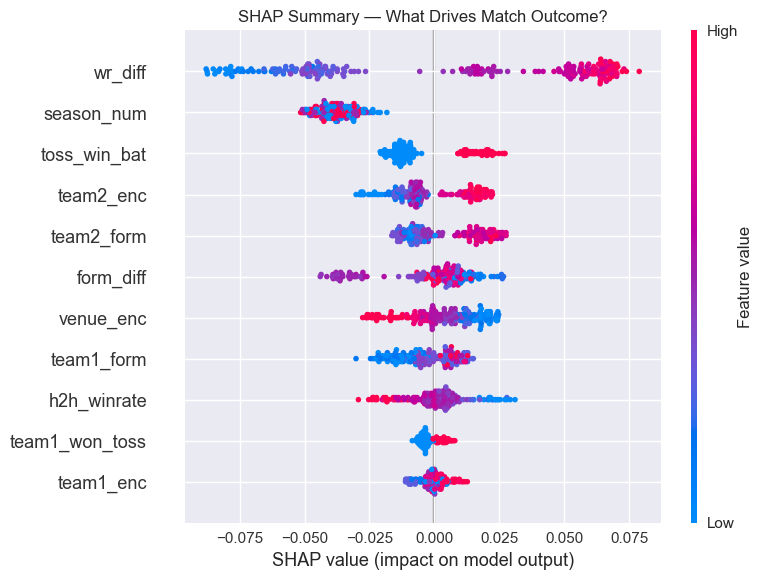

In [31]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test, feature_names=features, show=False)
plt.title('SHAP Summary — What Drives Match Outcome?')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


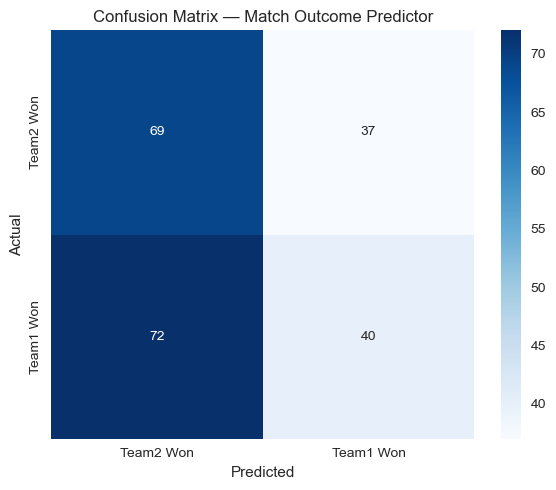

Model saved successfully!


In [32]:
# Confusion matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team2 Won', 'Team1 Won'],
            yticklabels=['Team2 Won', 'Team1 Won'])
plt.title('Confusion Matrix — Match Outcome Predictor')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Save model
import joblib
joblib.dump(rf, 'ipl_match_predictor.pkl')
joblib.dump(le, 'team_encoder.pkl')
joblib.dump(venue_enc, 'venue_encoder.pkl')

print("Model saved successfully!")

In [35]:
def predict_match(team1, team2, venue, team1_won_toss, toss_decision):
    t1 = le.transform([team1])[0]
    t2 = le.transform([team2])[0]
    v = venue_enc.transform([venue])[0]

    team_wins = matches['winner'].value_counts().to_dict()
    total = pd.concat([matches['team1'], matches['team2']]).value_counts().to_dict()
    t1_wr = team_wins.get(team1, 0) / total.get(team1, 1)
    t2_wr = team_wins.get(team2, 0) / total.get(team2, 1)
    wr_diff = t1_wr - t2_wr

    t1_matches = matches[(matches['team1'] == team1) | (matches['team2'] == team1)].tail(10)
    t1_form = (t1_matches['winner'] == team1).mean()
    t2_matches = matches[(matches['team1'] == team2) | (matches['team2'] == team2)].tail(10)
    t2_form = (t2_matches['winner'] == team2).mean()
    form_diff = t1_form - t2_form

    h2h = matches[((matches['team1'] == team1) & (matches['team2'] == team2)) |
                  ((matches['team1'] == team2) & (matches['team2'] == team1))]
    h2h_wr = (h2h['winner'] == team1).sum() / len(h2h) if len(h2h) > 0 else 0.5

    toss_win_bat = 1 if toss_decision == 'bat' else 0

    # Exactly 11 features
    features_input = [[t1, t2, team1_won_toss, toss_win_bat,
                       h2h_wr, t1_form, t2_form, v,
                       wr_diff, form_diff, 2024]]

    prob = rf.predict_proba(features_input)[0]
    winner = team1 if prob[1] > prob[0] else team2

    print(f"\n{'='*45}")
    print(f"  {team1} vs {team2}")
    print(f"  Venue: {venue}")
    print(f"{'='*45}")
    print(f"  {team1} win probability:  {prob[1]*100:.1f}%")
    print(f"  {team2} win probability:  {prob[0]*100:.1f}%")
    print(f"\n  Predicted Winner: ⭐ {winner}")
    print(f"{'='*45}\n")

# Test
predict_match(
    team1='Mumbai Indians',
    team2='Chennai Super Kings',
    venue='Wankhede Stadium',
    team1_won_toss=1,
    toss_decision='bat'
)


  Mumbai Indians vs Chennai Super Kings
  Venue: Wankhede Stadium
  Mumbai Indians win probability:  39.2%
  Chennai Super Kings win probability:  60.8%

  Predicted Winner: ⭐ Chennai Super Kings



In [37]:
# Check available venues
print(sorted(matches['venue'].unique()))

['Arun Jaitley Stadium', 'Arun Jaitley Stadium, Delhi', 'Barabati Stadium', 'Barsapara Cricket Stadium, Guwahati', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow', 'Brabourne Stadium', 'Brabourne Stadium, Mumbai', 'Buffalo Park', 'De Beers Diamond Oval', 'Dr DY Patil Sports Academy', 'Dr DY Patil Sports Academy, Mumbai', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Eden Gardens, Kolkata', 'Feroz Shah Kotla', 'Green Park', 'Himachal Pradesh Cricket Association Stadium', 'Himachal Pradesh Cricket Association Stadium, Dharamsala', 'Holkar Cricket Stadium', 'JSCA International Stadium Complex', 'Kingsmead', 'M Chinnaswamy Stadium', 'M Chinnaswamy Stadium, Bengaluru', 'M.Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'MA Chidambaram Stadium, Chepauk', 'MA Chidambaram Stadium, Chepauk, Chennai', 'Maharaja Yadavindra Singh Internation

In [38]:
predict_match(
    team1='Gujarat Titans',
    team2='Rajasthan Royals',
    venue='Narendra Modi Stadium, Ahmedabad',
    team1_won_toss=0,
    toss_decision='bat'
)


  Gujarat Titans vs Rajasthan Royals
  Venue: Narendra Modi Stadium, Ahmedabad
  Gujarat Titans win probability:  48.6%
  Rajasthan Royals win probability:  51.4%

  Predicted Winner: ⭐ Rajasthan Royals



In [42]:
predict_match(
    team1='Royal Challengers Bengaluru',
    team2='Kolkata Knight Riders',
    venue='M Chinnaswamy Stadium',
    team1_won_toss=1,
    toss_decision='field'
)

predict_match(
    team1='Gujarat Titans',
    team2='Rajasthan Royals',
    venue='Narendra Modi Stadium, Ahmedabad',
    team1_won_toss=0,
    toss_decision='bat'
)


  Royal Challengers Bengaluru vs Kolkata Knight Riders
  Venue: M Chinnaswamy Stadium
  Royal Challengers Bengaluru win probability:  47.8%
  Kolkata Knight Riders win probability:  52.2%

  Predicted Winner: ⭐ Kolkata Knight Riders


  Gujarat Titans vs Rajasthan Royals
  Venue: Narendra Modi Stadium, Ahmedabad
  Gujarat Titans win probability:  48.6%
  Rajasthan Royals win probability:  51.4%

  Predicted Winner: ⭐ Rajasthan Royals



In [43]:
import sqlite3
import pandas as pd

# Load CSV files
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

# Create SQLite database
conn = sqlite3.connect("ipl.db")

# Store data as SQL tables
matches.to_sql("matches", conn, if_exists="replace", index=False)
deliveries.to_sql("deliveries", conn, if_exists="replace", index=False)

print("Database created successfully!")

# Close connection
conn.close()

Database created successfully!


In [44]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("ipl.db")

In [45]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,matches
1,deliveries


In [46]:
query = """
SELECT winner,
       COUNT(*) AS wins
FROM matches
WHERE winner IS NOT NULL
GROUP BY winner
ORDER BY wins DESC
LIMIT 10;
"""

top_teams = pd.read_sql(query, conn)
top_teams

,winner,wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bangalore,116
4,Rajasthan Royals,112
5,Sunrisers Hyderabad,88
6,Kings XI Punjab,88
7,Delhi Daredevils,67
8,Delhi Capitals,48
9,Deccan Chargers,29


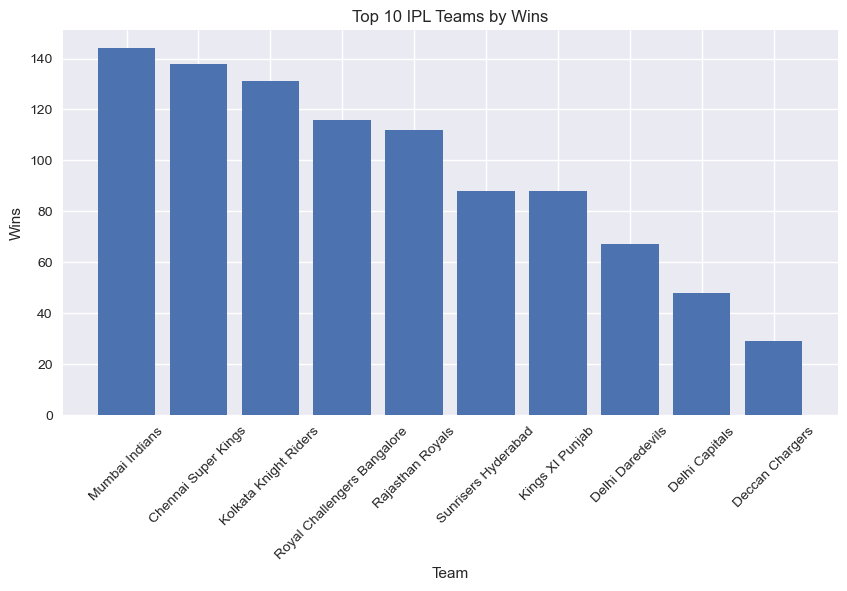

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top_teams["winner"], top_teams["wins"])

plt.title("Top 10 IPL Teams by Wins")

plt.xlabel("Team")

plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.show()

In [48]:
query = """
SELECT batter,
       SUM(batsman_runs) AS total_runs
FROM deliveries
GROUP BY batter
ORDER BY total_runs DESC
LIMIT 10;
"""

top_batsmen = pd.read_sql(query, conn)

top_batsmen

,batter,total_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


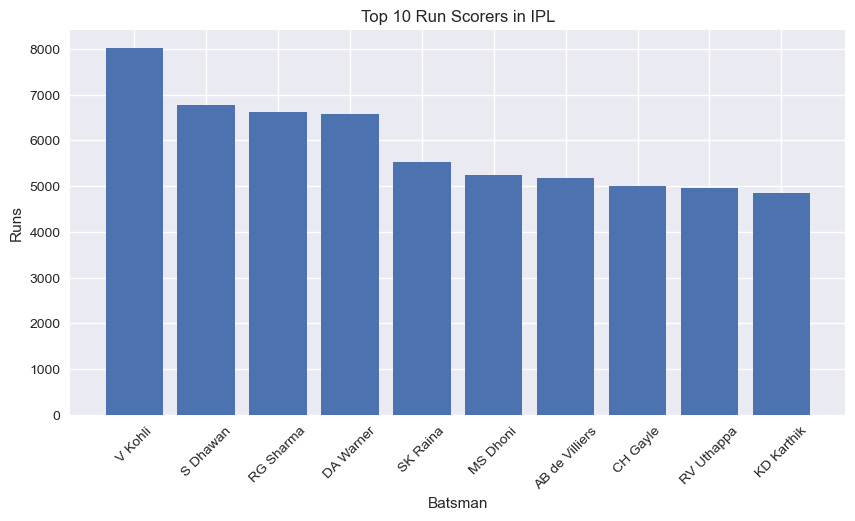

In [49]:
plt.figure(figsize=(10,5))

plt.bar(top_batsmen["batter"], top_batsmen["total_runs"])

plt.xticks(rotation=45)

plt.title("Top 10 Run Scorers in IPL")

plt.xlabel("Batsman")

plt.ylabel("Runs")

plt.show()

In [50]:
query = """
SELECT bowler,
       COUNT(*) AS wickets
FROM deliveries
WHERE player_dismissed IS NOT NULL
AND dismissal_kind NOT IN ('run out','retired hurt','obstructing the field')
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 10;
"""

top_bowlers = pd.read_sql(query, conn)

top_bowlers

,bowler,wickets
0,YS Chahal,205
1,PP Chawla,192
2,DJ Bravo,183
3,B Kumar,181
4,SP Narine,180
5,R Ashwin,180
6,A Mishra,174
7,SL Malinga,170
8,JJ Bumrah,168
9,RA Jadeja,160


In [51]:
query = """
SELECT batter,
       COUNT(*) AS sixes
FROM deliveries
WHERE batsman_runs = 6
GROUP BY batter
ORDER BY sixes DESC
LIMIT 10;
"""

top_sixes = pd.read_sql(query, conn)

top_sixes

,batter,sixes
0,CH Gayle,359
1,RG Sharma,281
2,V Kohli,273
3,AB de Villiers,253
4,MS Dhoni,252
5,DA Warner,236
6,KA Pollard,224
7,AD Russell,209
8,SV Samson,206
9,SK Raina,204


In [52]:
query = """
SELECT batter,
       COUNT(*) AS fours
FROM deliveries
WHERE batsman_runs = 4
GROUP BY batter
ORDER BY fours DESC
LIMIT 10;
"""

top_fours = pd.read_sql(query, conn)

top_fours

,batter,fours
0,S Dhawan,768
1,V Kohli,708
2,DA Warner,663
3,RG Sharma,599
4,SK Raina,506
5,G Gambhir,492
6,RV Uthappa,481
7,AM Rahane,479
8,KD Karthik,466
9,F du Plessis,422


In [53]:
query = """
SELECT
    winner AS team,
    COUNT(*) AS wins
FROM matches
WHERE winner IS NOT NULL
GROUP BY winner
ORDER BY wins DESC;
"""

team_wins = pd.read_sql(query, conn)

team_wins

,team,wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bangalore,116
4,Rajasthan Royals,112
5,Sunrisers Hyderabad,88
6,Kings XI Punjab,88
7,Delhi Daredevils,67
8,Delhi Capitals,48
9,Deccan Chargers,29


In [54]:
query = """
SELECT
    team,
    COUNT(*) AS matches_played
FROM
(
    SELECT team1 AS team FROM matches
    UNION ALL
    SELECT team2 AS team FROM matches
)
GROUP BY team
ORDER BY matches_played DESC;
"""

matches_played = pd.read_sql(query, conn)

matches_played

,team,matches_played
0,Mumbai Indians,261
1,Kolkata Knight Riders,251
2,Royal Challengers Bangalore,240
3,Chennai Super Kings,238
4,Rajasthan Royals,221
5,Kings XI Punjab,190
6,Sunrisers Hyderabad,182
7,Delhi Daredevils,161
8,Delhi Capitals,91
9,Deccan Chargers,75


In [55]:
team_stats = pd.merge(matches_played,
                      team_wins,
                      left_on="team",
                      right_on="team")

team_stats["win_percentage"] = (
    team_stats["wins"] /
    team_stats["matches_played"] * 100
).round(2)

team_stats.sort_values("win_percentage",
                       ascending=False)

,team,matches_played,wins,win_percentage
15,Rising Pune Supergiant,16,10,62.50
12,Gujarat Titans,45,28,62.22
3,Chennai Super Kings,238,138,57.98
0,Mumbai Indians,261,144,55.17
13,Lucknow Super Giants,44,24,54.55
8,Delhi Capitals,91,48,52.75
1,Kolkata Knight Riders,251,131,52.19
4,Rajasthan Royals,221,112,50.68
6,Sunrisers Hyderabad,182,88,48.35
2,Royal Challengers Bangalore,240,116,48.33


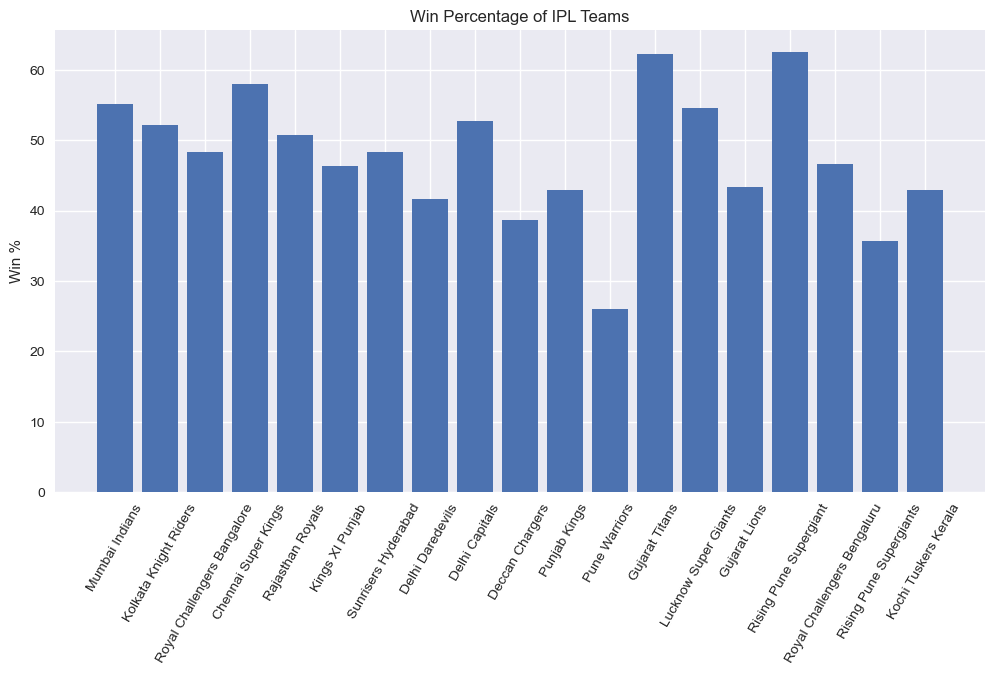

In [56]:
plt.figure(figsize=(12,6))

plt.bar(team_stats["team"],
        team_stats["win_percentage"])

plt.xticks(rotation=60)

plt.ylabel("Win %")

plt.title("Win Percentage of IPL Teams")

plt.show()

# Venue Analytics

## 1. Top IPL Venues by Matches Hosted

### Objective
Identify the stadiums that have hosted the highest number of IPL matches.

### Methodology
The `matches` table is queried using SQL. The data is grouped by venue and the total number of matches hosted at each venue is calculated using the `COUNT(*)` aggregation function.

### Expected Outcome
This analysis highlights the most frequently used IPL venues and helps understand where the majority of IPL matches have been played.

In [63]:
query = """
SELECT
    venue,
    COUNT(*) AS matches
FROM matches
GROUP BY venue
ORDER BY matches DESC;
"""

venue_matches = pd.read_sql(query, conn)

venue_matches.head(10)

,venue,matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Rajiv Gandhi International Stadium, Uppal",49
5,"MA Chidambaram Stadium, Chepauk",48
6,Sawai Mansingh Stadium,47
7,Dubai International Cricket Stadium,46
8,"Wankhede Stadium, Mumbai",45
9,"Punjab Cricket Association Stadium, Mohali",35


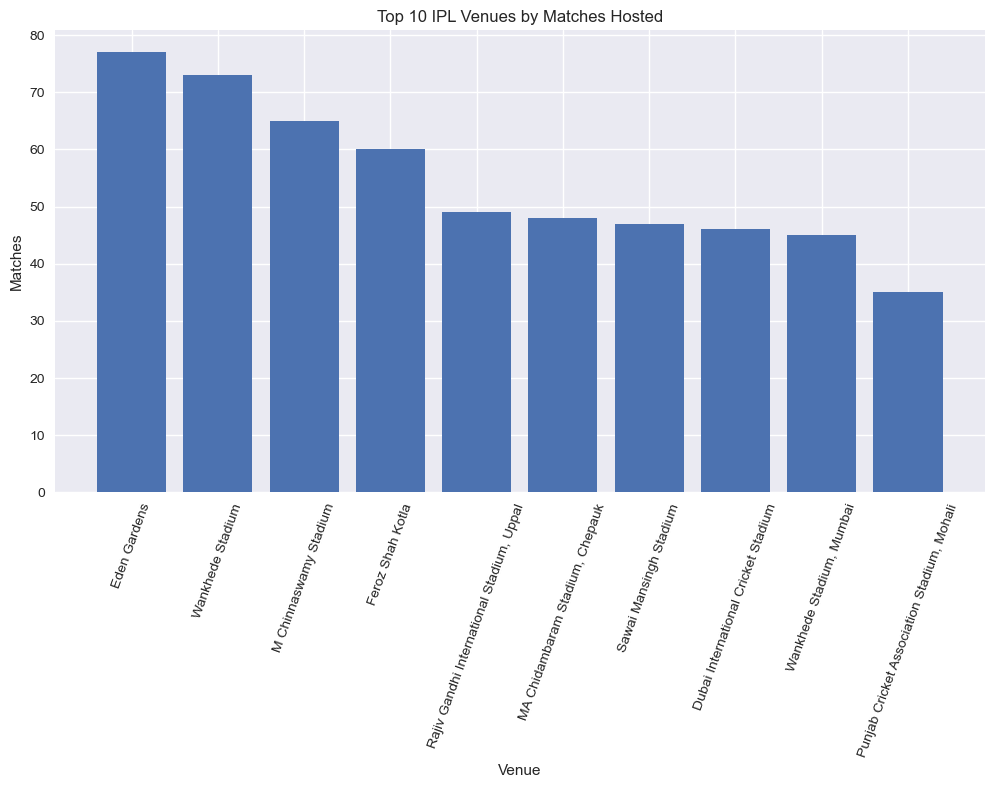

In [58]:
plt.figure(figsize=(12,6))

plt.bar(
    venue_matches["venue"][:10],
    venue_matches["matches"][:10]
)

plt.xticks(rotation=70)

plt.title("Top 10 IPL Venues by Matches Hosted")

plt.xlabel("Venue")

plt.ylabel("Matches")

plt.show()

### 📊 Key Findings

- Eden Gardens has hosted the highest number of IPL matches.
- Wankhede Stadium is another frequently used venue due to its importance in IPL history.
- Most of the top venues belong to major cricketing cities, reflecting their role in hosting high-profile matches.

### Business Impact

Understanding venue usage helps identify key stadiums that consistently host IPL matches. Such information can be useful while studying venue-specific team performance and match outcome trends.

## 2. Highest Scoring IPL Venues

### Objective

Identify the IPL venues with the highest average first innings score.

### Methodology

Using SQL, the average first innings target score (`target_runs`) is calculated for each venue. The venues are then ranked in descending order based on their average first innings score.

### Expected Outcome

This analysis identifies batting-friendly venues where teams generally post higher totals.

In [68]:
query = """
SELECT
    venue,
    ROUND(AVG(target_runs),2) AS avg_first_innings_score
FROM matches
WHERE target_runs IS NOT NULL
GROUP BY venue
ORDER BY avg_first_innings_score DESC;
"""

venue_scores = pd.read_sql(query, conn)

venue_scores.head(10)

,venue,avg_first_innings_score
0,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,232.50
1,"Himachal Pradesh Cricket Association Stadium, ...",203.00
2,"Arun Jaitley Stadium, Delhi",200.06
3,"M Chinnaswamy Stadium, Bengaluru",197.21
4,"Eden Gardens, Kolkata",196.63
5,"Punjab Cricket Association IS Bindra Stadium, ...",191.20
6,"Rajiv Gandhi International Stadium, Uppal, Hyd...",189.38
7,Brabourne Stadium,181.40
8,"Barsapara Cricket Stadium, Guwahati",181.00
9,"Sawai Mansingh Stadium, Jaipur",180.50


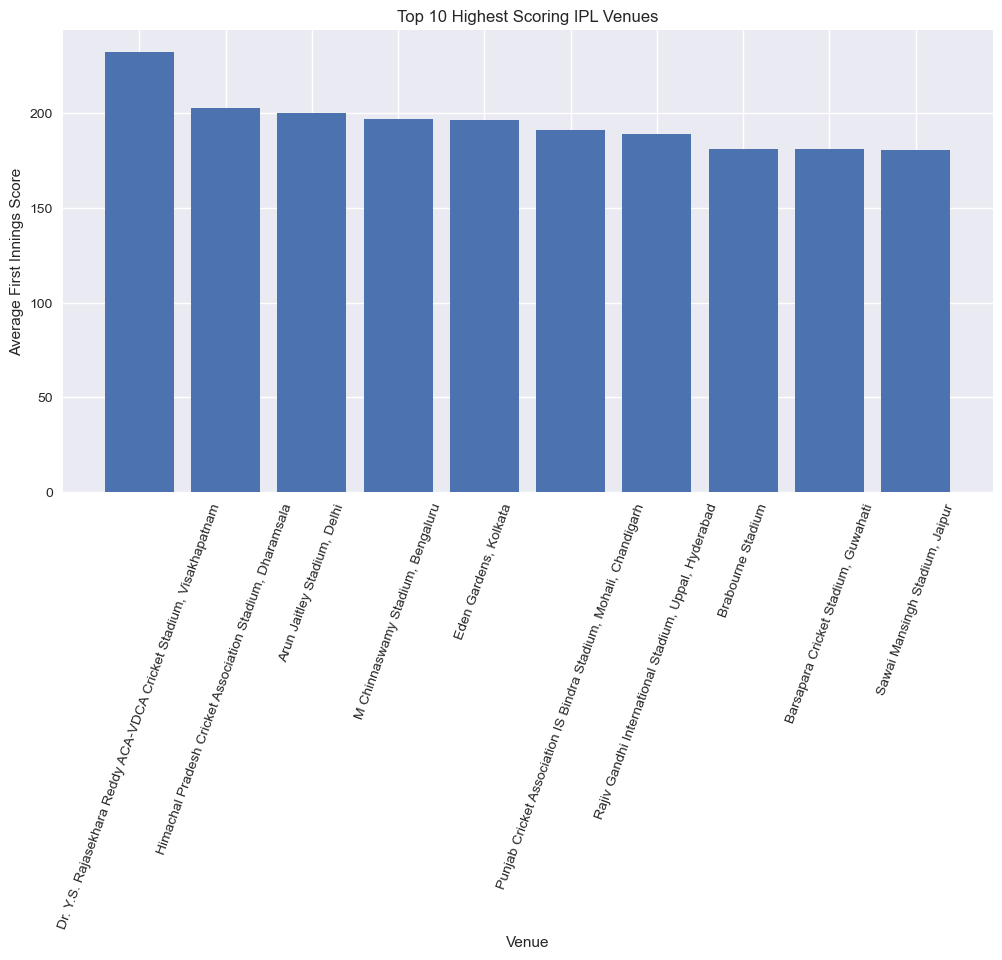

In [69]:
plt.figure(figsize=(12,6))

plt.bar(
    venue_scores["venue"][:10],
    venue_scores["avg_first_innings_score"][:10]
)

plt.xticks(rotation=70)

plt.title("Top 10 Highest Scoring IPL Venues")

plt.xlabel("Venue")

plt.ylabel("Average First Innings Score")

plt.show()

## 📊 Key Findings

- Some IPL venues consistently record higher first innings scores.
- Batting-friendly pitches contribute to higher average totals.
- Venue characteristics significantly influence scoring patterns.

## 💼 Business Impact

Understanding venue-wise scoring trends helps teams prepare better batting strategies and improves the performance of venue-aware match prediction models.

## 3. Venue Statistics

### Objective

Summarize important performance statistics for IPL venues.

### Methodology

SQL aggregation functions are used to calculate the total number of matches played and the average first innings target score for each venue.

### Expected Outcome

This analysis provides a consolidated overview of venue performance, helping identify the most frequently used and highest-scoring stadiums.

In [70]:
query = """
SELECT
    venue,
    COUNT(*) AS total_matches,
    ROUND(AVG(target_runs),2) AS avg_first_innings_score
FROM matches
WHERE target_runs IS NOT NULL
GROUP BY venue
ORDER BY total_matches DESC;
"""

venue_stats = pd.read_sql(query, conn)

venue_stats.head(10)

,venue,total_matches,avg_first_innings_score
0,Eden Gardens,77,157.74
1,Wankhede Stadium,73,167.03
2,M Chinnaswamy Stadium,64,167.34
3,Feroz Shah Kotla,59,162.20
4,"Rajiv Gandhi International Stadium, Uppal",49,154.84
5,"MA Chidambaram Stadium, Chepauk",48,167.02
6,Sawai Mansingh Stadium,47,156.91
7,Dubai International Cricket Stadium,46,164.76
8,"Wankhede Stadium, Mumbai",45,178.11
9,"Punjab Cricket Association Stadium, Mohali",35,164.29


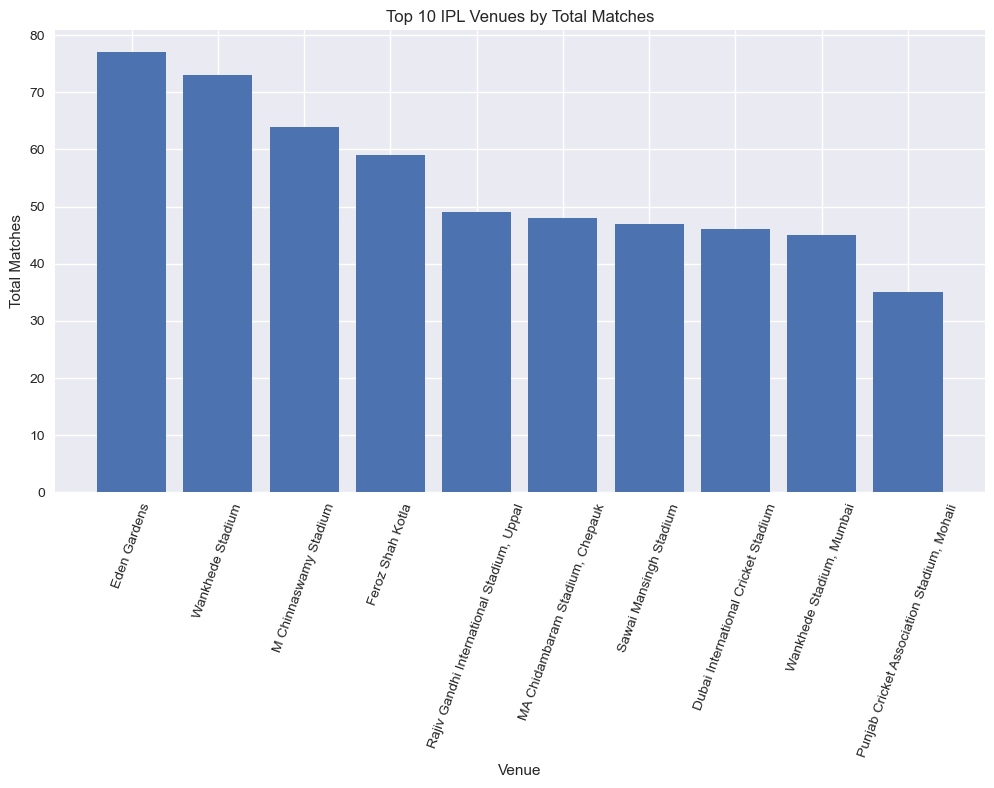

In [71]:
plt.figure(figsize=(12,6))

plt.bar(
    venue_stats["venue"][:10],
    venue_stats["total_matches"][:10]
)

plt.xticks(rotation=70)

plt.title("Top 10 IPL Venues by Total Matches")

plt.xlabel("Venue")

plt.ylabel("Total Matches")

plt.show()

## 📊 Key Findings

- A few venues consistently host the majority of IPL matches.
- Frequently used stadiums also provide large amounts of historical performance data.
- Venue statistics help identify important locations in IPL history.

## 💼 Business Impact

Venue statistics can support scheduling analysis, venue-specific strategy planning, and improve feature engineering for machine learning models.

# Head-to-Head Analytics

## 1. Head-to-Head Record Between Teams

### Objective

Analyze the historical performance between IPL te`ams by comparing their head-to-head records.

### Methodology

The analysis counts the number of matches played between two teams and calculates the number of wins for each team using SQL aggregation.

### Expected Outcome

This analysis highlights team dominance in historical rivalries and provides useful insights for match prediction.

In [74]:
query = """
SELECT
    team1,
    team2,
    COUNT(*) AS matches_played
FROM matches
GROUP BY team1, team2
ORDER BY matches_played DESC;
"""

head_to_head = pd.read_sql(query, conn)

head_to_head.head(10)

,team1,team2,matches_played
0,Chennai Super Kings,Mumbai Indians,22
1,Royal Challengers Bangalore,Kolkata Knight Riders,19
2,Royal Challengers Bangalore,Mumbai Indians,19
3,Kolkata Knight Riders,Mumbai Indians,18
4,Royal Challengers Bangalore,Chennai Super Kings,18
5,Chennai Super Kings,Rajasthan Royals,17
6,Mumbai Indians,Rajasthan Royals,17
7,Kolkata Knight Riders,Rajasthan Royals,16
8,Mumbai Indians,Kolkata Knight Riders,16
9,Kolkata Knight Riders,Chennai Super Kings,15


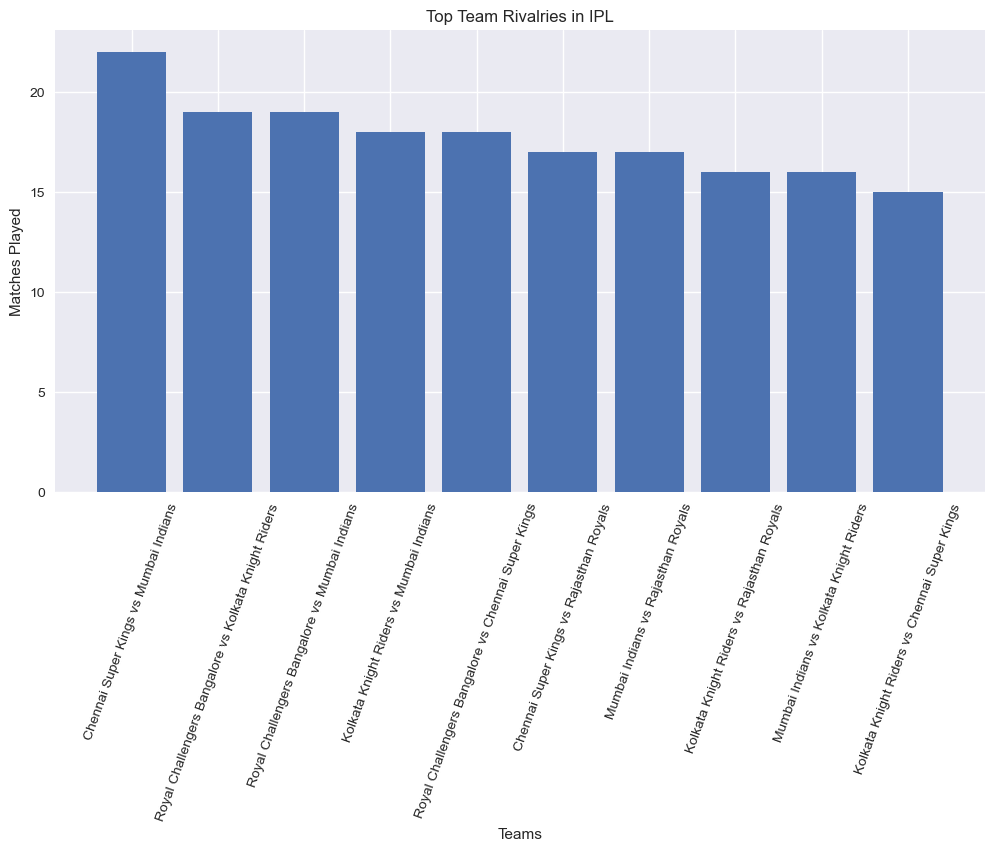

In [75]:
plt.figure(figsize=(12,6))

plt.bar(
    head_to_head["team1"][:10] + " vs " + head_to_head["team2"][:10],
    head_to_head["matches_played"][:10]
)

plt.xticks(rotation=70)

plt.title("Top Team Rivalries in IPL")

plt.xlabel("Teams")

plt.ylabel("Matches Played")

plt.show()

## 📊 Key Findings

- Certain team rivalries have occurred significantly more often than others.
- Long-standing franchises naturally have a richer head-to-head history.
- Rivalry analysis provides useful context for understanding historical matchups.

## 💼 Business Impact

Head-to-head statistics can be incorporated into machine learning models as a predictive feature and also help analysts evaluate historical team performance.

# 🏏 IPL Analytics & Match Outcome Prediction Platform

**Developed By:** Shibang Maity  
**Institution:** KIIT University, Bhubaneswar  

---

## 🚀 Live Demo

[![Open in Streamlit](https://static.streamlit.io/badges/streamlit_badge_black_white.svg)](https://shibang-ipl-analytics.streamlit.app/)

**Live App:** [https://shibang-ipl-analytics.streamlit.app/](https://shibang-ipl-analytics.streamlit.app/)

**GitHub:** [github.com/shibangmaity](https://github.com/shibangmaity)

---

---

## ✅ Conclusion & Deployment

This project successfully demonstrates:
- End-to-end IPL data analytics using Python and SQL
- Machine learning with Random Forest + XGBoost
- Explainable AI using SHAP
- Live deployment on Streamlit Cloud

## 🔗 Links

| Resource | Link |
|---|---|
| 🚀 Live App | https://shibang-ipl-analytics.streamlit.app/ |
| 💻 GitHub | https://github.com/shibangmaity |

**Developed by Shibang Maity — KIIT University 2026**